# Modeling KBest - Decision Tree - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import cross_validate,StratifiedGroupKFold,GridSearchCV
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

dt =  DecisionTreeClassifier(random_state=RANDOM_STATE)

xtrain_KB = pd.read_csv("xtrain_KB.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=dt,X=xtrain_KB,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,0.087219,0.008841,0.649571,1.0
1,0.088345,0.009012,0.649149,1.0
2,0.086090,0.008842,0.661694,1.0
3,0.087368,0.008804,0.645333,1.0
4,0.086874,0.008845,0.656884,1.0


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.6525263494143271


Le Decision Tree avec ses paramètres par défaut obtient un F1-macro moyen d’environ 0,653 en validation croisée. Les scores de validation varient entre environ 0,645 et 0,662, ce qui indique des performances relativement stables entre les différents folds.

En revanche, le F1-macro d’entraînement est égal à 1,00 sur les cinq folds. Le modèle parvient donc à classifier parfaitement les observations utilisées pour son entraînement.

L’écart important entre le score d’entraînement (1,00) et le score moyen de validation (0,653) met en évidence un surapprentissage important.

Cette baseline montre que le Decision Tree est trop complexe dans sa configuration par défaut. L’optimisation devra donc chercher à régulariser l’arbre afin de réduire cet écart et d’améliorer sa capacité de généralisation

## 3. Hyperparameter Tuning

In [3]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

grid_search =  GridSearchCV(estimator=dt,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)


grid_search.fit(
    X=xtrain_KB,
    y=ytrain,
    groups=kepid_train
)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [4]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5}
Best validation F1: 0.6911398897644938
Mean train F1: 0.7835403803745856
Std validation F1: 0.02158687165335901


L’optimisation du **Decision Tree** sélectionne `max_depth=10`, `max_features=0.5` et `min_samples_leaf=5`.

Le **F1-macro moyen** en validation passe d’environ **0,653** pour **la baseline à 0,691 après optimisation**, tandis que le **F1-macro moyen d’entraînement** diminue fortement **de 1,00 à environ 0,784**.

**L’écart entre les performances d’entraînement et de validation** passe donc d’environ **0,347 à 0,092**, ce qui montre **une forte réduction du surapprentissage**. La limitation de la profondeur de l’arbre et l’augmentation du nombre minimal d’observations par feuille empêchent le modèle de créer des règles trop spécifiques aux données d’entraînement.

Le **F1-macro de validation s’améliore simultanément**, ce qui **indique** que la **régularisation permet** au modèle **de mieux généraliser**.

**L’écart-type du score de validation** est d’environ **0,022**, ce qui **indique** toutefois **une variabilité légèrement plus importante entre les folds** que pour certaines autres combinaisons.

## 4. Final Evaluation

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_KB = pd.read_csv("xtest_KB.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_KB)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7202944269190326
Precision macro : 0.6871125696723447
Recall macro : 0.6953332973291658
F1 macro : 0.690838992615559


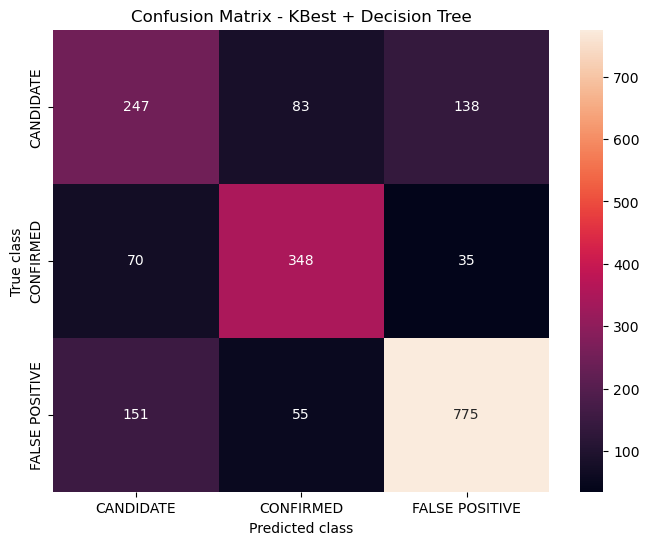

In [ ]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - KBest + Decision Tree")

plt.show()

La matrice de confusion montre que le modèle **distingue correctement la majorité des objets** `CONFIRMED` et `FALSE POSITIVE`.

Pour les **453 objets** `CONFIRMED`, **348 sont correctement classés**, tandis que 70 sont prédits `CANDIDATE` et 35 `FALSE POSITIVE`. Le modèle reconnaît donc relativement bien cette classe.

La classe `FALSE POSITIVE` est la **mieux identifiée** : **775 observations sur 981 sont correctement classées**. Les **principales erreurs** concernent **151 faux positifs** prédits comme `CANDIDATE`.

La classe `CANDIDATE` est **la plus difficile à identifier**. Sur **468 candidats**, seuls **247 sont correctement classés**, tandis que **83 sont prédits** `CONFIRMED` et surtout **138** comme `FALSE POSITIVE`.

Ces résultats suggèrent que **les candidats occupent une zone plus ambiguë de l’espace des variables** : certaines de leurs caractéristiques ressemblent à celles d’exoplanètes confirmées, tandis que d’autres ressemblent à celles de faux positifs. Cette difficulté explique le F1-score plus faible obtenu pour la classe `CANDIDATE`

## 5. Model Limits

C’est assez cohérent avec la nature même d’un **candidat KOI** : il s’agit précisément d’un objet dont le statut n’est pas encore suffisamment établi pour être confirmé ou rejeté. Donc il est intéressant de se demander si une partie de la difficulté du Machine Learning vient non seulement du modèle, mais aussi de l’ambiguïté intrinsèque de la cible `CANDIDATE`